In [1]:
import os
import pandas as pd
from tqdm import tqdm

label = 'pident_90'
genus_name = 'Escherichia'
base_folder = '/active-data/analysis_results/chr_pla/genus'

file_folder = f'{base_folder}/cor-pla_fraction_records/{genus_name}'
target_folder = f'{base_folder}/statistics_records/{genus_name}'
replicon_data = pd.read_csv(f'{target_folder}/replicon-plasmid_fraction-self_bitscore_statistics.csv')
NMS_replicons = replicon_data[replicon_data['ms-label'] == 'NMS_replicon'].reset_index(drop=True)

cut_value = 0.5
link_count = 0
NMS_links = []
with tqdm(total = len(NMS_replicons), desc=f'{genus_name}({len(NMS_replicons)})', leave=True, ncols=100, unit='B', unit_scale=True) as pbar:
    for i in NMS_replicons.index:
        rep_name = NMS_replicons['accession'][i]
        acc_n, replicon = rep_name.split('-')[0], rep_name.split('-')[1]
        pbar.update(1)
        try:
            cover_csv = pd.read_csv(f'{file_folder}/{acc_n}/{replicon}_coverage.csv')
            cover_csv = cover_csv[(cover_csv['id'].isin(NMS_replicons['accession'])) & ~(cover_csv['id'] == rep_name) & (cover_csv[f'coverage-{label}'] >= cut_value)]
            cover_csv['source'] = rep_name
            cover_csv = cover_csv[['source', 'id', f'coverage-{label}']]
            cover_csv.columns = ['source', 'target', 'coverage']
            NMS_links.append(cover_csv)
            link_count += len(cover_csv)
        except:
            continue

all_NMS_link_pd = pd.concat(NMS_links, ignore_index = True)

Escherichia(11232): 100%|███████████████████████████████████████| 11.2k/11.2k [04:19<00:00, 43.2B/s]


In [2]:
mob_type = pd.read_csv(f'{base_folder}/statistics_records/{genus_name}/annotations/NMS_replicon_mobtyper_results.tsv', sep='\t', index_col=0)
mob_type = mob_type.rename(columns={'id': 'accession'})
amr_type = pd.read_csv(f'{base_folder}/statistics_records/{genus_name}/annotations/NMS_replicon_AMRtyper_results.tsv', sep='\t', index_col=0)
amr_type = amr_type.drop_duplicates(subset=['accession'], keep='first')

folder = f'{base_folder}/statistics_records/{genus_name}'
plas_frac = replicon_data.copy()
plas_frac = plas_frac[plas_frac[f'category-{label}'].isin(['typical plasmid', 'intermediate replicon'])]

In [3]:
def plot_size_violin(ax, df, value_col, label_=True):
    layers = sorted(df['layer'].unique())
    data = [df[df['layer'] == l][value_col].values for l in layers]
    
    parts = ax.violinplot(
        data, positions=layers, widths=0.7,
        showmeans=False, showmedians=False, showextrema=False
    )
    
    for pc in parts['bodies']:
        pc.set_facecolor('#88aaff')
        pc.set_edgecolor('black')
        pc.set_alpha(0.4)

    box_plot = ax.boxplot(
        data,
        positions=layers,
        widths=0.2,
        patch_artist=True,
        showmeans=False,
        showfliers=False,
        medianprops={'color': 'crimson', 'linewidth': 1},
        boxprops={'facecolor': 'white', 'edgecolor': 'black', 'alpha': 0.8},
        whiskerprops={'color': 'black', 'linewidth': 1},
        showcaps=False
    )
    
    label = value_col.replace('_', ' ')
    if not label[0].isupper():
        label = label.capitalize()
        
    ax.tick_params(axis='both', pad=1)
    ax.set_xticks(layers)
    ax.set_xticklabels(layers)
    # ax.set_xlabel('Layer')
    if label_:
        ax.set_ylabel(label, labelpad=1)

def plot_stacked_percentage(ax, df, category_col, color_col, label_=True):
    counts = df.groupby(['layer', category_col]).size().unstack(fill_value=0)
    percent = counts.div(counts.sum(axis=1), axis=0) * 100

    color_dict = {}
    for cat in df[category_col].unique():
        color = df[df[category_col] == cat][color_col].iloc[0]
        if isinstance(color, str):
            color = eval(color)
        color_dict[cat] = color
    cats = percent.columns.tolist()
    plot_colors = [color_dict[col] for col in percent.columns]

    x = np.arange(len(percent.index))
    width = 0.9
    bottom = np.zeros(len(percent.index))

    for i, cat in enumerate(cats):
        if len(cat) > 0 and not cat[0].isupper():
            cat_label = cat[0].upper() + cat[1:]
        else:
            cat_label = cat
        ax.bar(
            x, percent[cat], width, bottom=bottom,
            label=cat_label, color=plot_colors[i], alpha=0.8,
        )
        for j, (p, raw_val) in enumerate(zip(percent[cat], counts[cat])):
            if p > 0:
                ax.text(
                    x[j], bottom[j] + p/2,
                    str(int(raw_val)),
                    ha='center', va='center', fontsize=6, color='black'
                )
        bottom += percent[cat]

    ax.set_xticks(x)
    ax.set_xticklabels(percent.index, rotation=0)
    ax.set_xlim(-0.5, len(x)-0.5)
    if label_:
        ax.set_ylabel('Percentage (%)', labelpad=1)
    # ax.set_xlabel('Layer')
    ax.set_ylim(0, 100)
    title_label = category_col.replace('_', ' ')
    if not title_label[0].isupper():
        title_label = title_label.capitalize()
    ax.tick_params(axis='both', pad=1)
    # ax.legend(title=title_label, bbox_to_anchor=(1.05, 1), loc='upper left')

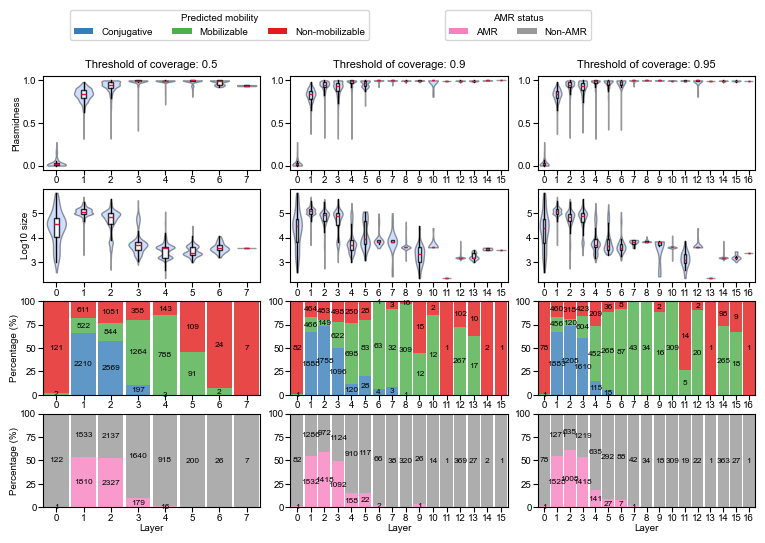

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

set1 = plt.cm.Set1.colors
mobility_map = {'non-mobilizable': set1[0], 'mobilizable': set1[2], 'conjugative': set1[1]}
amr_map = {'AMR': set1[-2], 'non-AMR': set1[-1]}

plt.rcParams["font.family"] = ["Arial"]
plt.rcParams.update({
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
})

fig = plt.figure(figsize=(7.5, 7.5))
ax_width = 0.29
ax_height = 0.125
ax_x_gap = 0.04
ax_y_gap = 0.025
thr_list = [0.5, 0.9, 0.95]
label_list = ["0.5", "0.9", "0.95"]

for idx, (thr, lab) in enumerate(zip(thr_list, label_list)):
    NMS_link = all_NMS_link_pd[all_NMS_link_pd['coverage'] >= thr]
    NMS_link = NMS_link[(NMS_link['source'].isin(plas_frac['accession'])) & (NMS_link['target'].isin(plas_frac['accession']))]
    link_replicon = set(NMS_link['source']) | set(NMS_link['target'])
    
    plas_frac = plas_frac[plas_frac['accession'].isin(link_replicon)][['organism', 'accession', 'size', f'average plasmid fraction-{label}', 'cp-label', f'category-{label}']]
    plas_frac['log10_size'] = np.log10(plas_frac['size'])
    plas_frac = pd.merge(plas_frac, mob_type[['accession', 'predicted_mobility']], on='accession', how='left')
    plas_frac = pd.merge(plas_frac, amr_type, on='accession', how='left')
    plas_frac['color_mobility'] = plas_frac['predicted_mobility'].map(mobility_map)
    plas_frac['color_amr'] = plas_frac['AMR_type'].map(amr_map)
    
    init_rep = set(plas_frac[plas_frac[f'average plasmid fraction-{label}'] < 0.3]['accession'])
    
    link_rep_dict = {0: init_rep}
    i = 0
    temp_set = init_rep
    
    while True:
        next_link = NMS_link[(NMS_link['source'].isin(link_rep_dict[i])) | (NMS_link['target'].isin(link_rep_dict[i]))]
        next_rep = (set(next_link['source']) | set(next_link['target'])) - temp_set
        if len(next_rep) == 0:
            break
        link_rep_dict[i+1] = next_rep
        temp_set = temp_set | next_rep
        i += 1
    
    plas_frac['layer'] = plas_frac['accession'].map({acc: k for k, acc_set in link_rep_dict.items() for acc in acc_set})
    plas_frac = plas_frac[plas_frac['layer'].notna()]
    plas_frac['layer'] = plas_frac['layer'].astype(int)
    plas_frac['plasmidness'] = plas_frac[f'average plasmid fraction-{label}']

    if idx == 0:
        label_ = True
    else:
        label_ = False
    
    ax_plasmidness = fig.add_axes([0.05+idx*(ax_width+ax_x_gap),0.78,ax_width,ax_height])
    plot_size_violin(ax_plasmidness, plas_frac, 'plasmidness', label_=label_)
    ax_plasmidness.set_title(f"Threshold of coverage: {lab}")
    ax_size = fig.add_axes([0.05+idx*(ax_width+ax_x_gap),0.78-(ax_height+ax_y_gap),ax_width,ax_height])
    plot_size_violin(ax_size, plas_frac, 'log10_size', label_=label_)
    ax_mob = fig.add_axes([0.05+idx*(ax_width+ax_x_gap),0.78-(ax_height+ax_y_gap)*2,ax_width,ax_height])
    plot_stacked_percentage(ax_mob, plas_frac, category_col='predicted_mobility', color_col='color_mobility', label_=label_)
    ax_amr = fig.add_axes([0.05+idx*(ax_width+ax_x_gap),0.78-(ax_height+ax_y_gap)*3,ax_width,ax_height])
    plot_stacked_percentage(ax_amr, plas_frac, category_col='AMR_type', color_col='color_amr', label_=label_)
    ax_amr.set_xlabel('Layer', labelpad=1)

mob_elements = [Patch(facecolor=set1[1],label='Conjugative'), 
                Patch(facecolor=set1[2],label='Mobilizable'), 
                Patch(facecolor=set1[0],label='Non-mobilizable')]
fig.legend(handles=mob_elements, loc='upper left',bbox_to_anchor=(0.08,1),fontsize=7,title='Predicted mobility',ncol=3)

amr_elements = [Patch(facecolor=set1[-2],label='AMR'), 
                Patch(facecolor=set1[-1],label='Non-AMR')]
fig.legend(handles=amr_elements, loc='upper left',bbox_to_anchor=(0.58,1),fontsize=7,title='AMR status',ncol=2)

rect = plt.Rectangle((0, 0), 1, 1, transform=fig.transFigure, facecolor='none', edgecolor='black', linewidth=2)
# fig.patches.append(rect)

figure_fold = f'{base_folder}/figures'
os.chdir(figure_fold)
plt.savefig(f"S_layer_alter_coverage.svg", bbox_inches="tight", transparent=True)
plt.savefig(f"S_layer_alter_coverage.png", dpi=1000, bbox_inches="tight", transparent=True)
plt.show()